In [ ]:
import kagglehub
import pandas as pd
import os

# 1. Download the dataset (this just downloads the files to a local cache)
path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

print("Path to dataset files:", path)

# 2. List all files in the downloaded directory to find the correct CSV name
print("\nFiles in this dataset:")
files = []
for root, dirs, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(root, filename))
        files.append(os.path.join(root, filename))

# 3. Load the CSV file
# We look for the first CSV file found in the directory
csv_file = next((f for f in files if f.endswith('.csv')), None)

if csv_file:
    print(f"\nLoading: {csv_file}")
    df = pd.read_csv(csv_file)
    print("Success! Dataset loaded.")
    print(df.head())
else:
    print("\nNo CSV file found in the dataset.")

100%|██████████| 115M/115M [00:00<00:00, 154MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1

Files in this dataset:
/root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1/Reviews.csv

Loading: /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1/Reviews.csv
Success! Dataset loaded.
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1            

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print(df.shape)

(568454, 10)


In [ ]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [ ]:
#Data quality checks
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
# Drop rows where critical fields are missing
df = df.dropna(subset=['UserId', 'Score', 'Time', 'Text'])

# Fill non-critical missing values
df['ProfileName'] = df['ProfileName'].fillna('Unknown')
df['HelpfulnessNumerator'] = df['HelpfulnessNumerator'].fillna(0)
df['Summary'] = df['Summary'].fillna('')

In [ ]:
df['review_text'] = df['Summary'] + ' ' + df['Text']

In [ ]:
# Convert 'Time' to datetime format
df['Time'] = pd.to_datetime(df['Time'], unit='s')

# Extract year, month, and day if needed for future analysis
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['Day'] = df['Time'].dt.day

# Check the updated DataFrame
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_text,Year,Month,Day
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...,2011,4,27
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...,2012,9,7
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha...",2008,8,18
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...,2011,6,13
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...,2012,10,21


In [ ]:
import numpy as np

# Text processing
import re
import spacy

# Visualization
import matplotlib.pyplot as plt

# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Load spaCy model for lemmatization
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def normalize_text(text):
    # Convert all text to lowercase for uniformity
    text = text.lower()

    # Remove URLs as they do not contribute to sentiment
    text = re.sub(r'http\S+|www\S+', '', text)


    # Remove numbers, punctuation, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply normalization
df['cleaned_review'] = df['review_text'].apply(normalize_text)

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_text,Year,Month,Day,cleaned_review
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...,2011,4,27,good quality dog food i have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...,2012,9,7,not as advertised product arrived labeled as j...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha...",2008,8,18,delight says it all this is a confection that ...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...,2011,6,13,cough medicine if you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...,2012,10,21,great taffy great taffy at a great price there...


In [ ]:
# Words that must be kept because they affect sentiment
negation_words = {"no",
    "not",
    "nor",
    "never",
    "none",
    "nobody",
    "nothing",
    "neither",
    "nowhere","cannot",
    "cant",
    "without",
    "lack",
    "lacking","dont",
    "doesnt",
    "didnt",
    "isnt",
    "arent",
    "wasnt",
    "werent",
    "havent",
    "hasnt",
    "hadnt",
    "wont",
    "wouldnt",
    "shouldnt",
    "couldnt",
    "mustnt",
     "don't",
    "doesn't",
    "didn't",
    "isn't",
    "aren't",
    "wasn't",
    "weren't",
    "haven't",
    "hasn't",
    "hadn't",
    "won't",
    "wouldn't",
    "shouldn't",
    "couldn't",
    "mustn't",
    "can't"
}

# Create a safe stopword list by excluding negations
safe_stopwords = stop_words - negation_words

In [ ]:
def remove_stopwords(text):
    # Remove stopwords but keep negation words to preserve sentiment
    return ' '.join([word for word in text.split() if word not in safe_stopwords])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_text,Year,Month,Day,cleaned_review
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...,2011,4,27,good quality dog food bought several vitality ...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...,2012,9,7,not advertised product arrived labeled jumbo s...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha...",2008,8,18,delight says confection around centuries light...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...,2011,6,13,cough medicine looking secret ingredient robit...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...,2012,10,21,great taffy great taffy great price wide assor...


In [ ]:
#EDA
#basic data overview
# Display dataset shape: number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("Columns:", df.columns.tolist())

# Check data types and non-null counts
df.info()

Dataset shape: (568454, 15)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_text', 'Year', 'Month', 'Day', 'cleaned_review']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Id                      568454 non-null  int64         
 1   ProductId               568454 non-null  object        
 2   UserId                  568454 non-null  object        
 3   ProfileName             568454 non-null  object        
 4   HelpfulnessNumerator    568454 non-null  int64         
 5   HelpfulnessDenominator  568454 non-null  int64         
 6   Score                   568454 non-null  int64         
 7   Time                    568454 non-null  datetime64[ns]
 8   Summary                 568454 non-null  object  

In [ ]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print("Missing values per column:")
print(missing_values)

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100
print("Missing value percentage:")
print(missing_percentage)

Missing values per column:
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
review_text               0
Year                      0
Month                     0
Day                       0
cleaned_review            0
dtype: int64
Missing value percentage:
Id                        0.0
ProductId                 0.0
UserId                    0.0
ProfileName               0.0
HelpfulnessNumerator      0.0
HelpfulnessDenominator    0.0
Score                     0.0
Time                      0.0
Summary                   0.0
Text                      0.0
review_text               0.0
Year                      0.0
Month                     0.0
Day                       0.0
cleaned_review            0.0
dtype: float64


In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates to prevent bias
df.drop_duplicates(inplace=True)

Number of duplicate rows: 0


Unique scores: [5 1 4 2 3]
Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


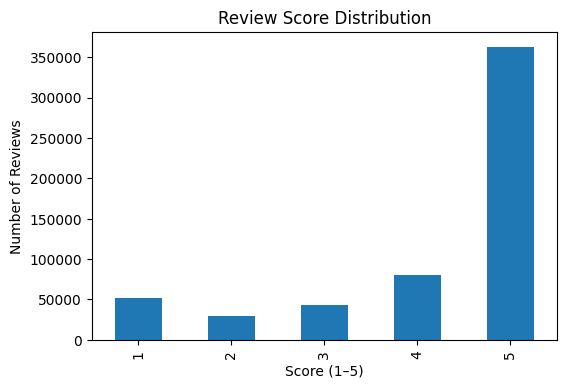

In [ ]:
# Display unique score values
print("Unique scores:", df['Score'].unique())

# Count number of reviews per score
score_distribution = df['Score'].value_counts().sort_index()
print("Score distribution:")
print(score_distribution)

# Visualize score distribution to detect imbalance
score_distribution.plot(kind='bar', figsize=(6,4))
plt.title("Review Score Distribution")
plt.xlabel("Score (1–5)")
plt.ylabel("Number of Reviews")
plt.show()

count    568454.000000
mean         44.498077
std          42.865155
min           0.000000
25%          20.000000
50%          32.000000
75%          53.000000
max        1999.000000
Name: review_length, dtype: float64


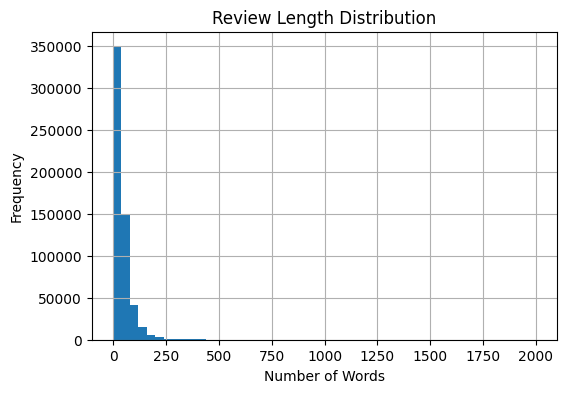

In [ ]:
# Calculate word count for each review
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Display basic statistics of review length
print(df['review_length'].describe())

# Visualize review length distribution
plt.figure(figsize=(6,4))
df['review_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Identify very short reviews (low information content)
short_reviews = df[df['review_length'] < 3]

print("Number of very short reviews:", short_reviews.shape[0])

# Optionally remove extremely short reviews
df = df[df['review_length'] >= 3]

Number of very short reviews: 2


count    568452.000000
mean          0.407863
std           0.462069
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           3.000000
Name: helpfulness_ratio, dtype: float64


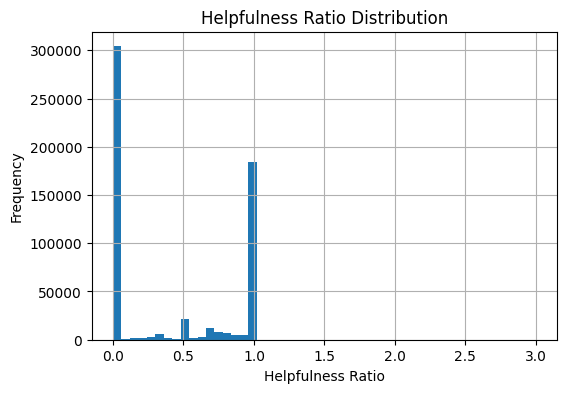

In [ ]:
# Create helpfulness ratio feature
df['helpfulness_ratio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

# Display helpfulness statistics
print(df['helpfulness_ratio'].describe())

# Plot helpfulness ratio distribution
plt.figure(figsize=(6,4))
df['helpfulness_ratio'].hist(bins=50)
plt.title("Helpfulness Ratio Distribution")
plt.xlabel("Helpfulness Ratio")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Number of unique products
print("Unique products:", df['ProductId'].nunique())

# Number of unique users
print("Unique users:", df['UserId'].nunique())

# Reviews per product
reviews_per_product = df.groupby('ProductId').size()
print("Average reviews per product:", reviews_per_product.mean())

# Reviews per user
reviews_per_user = df.groupby('UserId').size()
print("Average reviews per user:", reviews_per_user.mean())

Unique products: 74258
Unique users: 256057
Average reviews per product: 7.655094400603302
Average reviews per user: 2.2200213233772166


In [ ]:
#sentiment labelling
# Install if not already installed
!pip install nltk



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Preparation ---

# Filter out 3-star reviews (Neutral reviews often confuse the model)
df_svm = df[df['Score'] != 3].copy()

# Create Ground Truth Labels:
# 0 = Negative (Score 1 & 2)
# 1 = Positive (Score 4 & 5)
df_svm['label'] = df_svm['Score'].apply(lambda x: 1 if x > 3 else 0)

print(f"Original Dataset Size: {len(df)}")
print(f"Dataset Size for SVM (no 3-stars): {len(df_svm)}")
print(f"Class Balance:\n{df_svm['label'].value_counts()}")




Original Dataset Size: 568452
Dataset Size for SVM (no 3-stars): 525812
Class Balance:
label
1    443775
0     82037
Name: count, dtype: int64


In [ ]:
 #--- 2. Train/Test Split ---

# Split data: 80% for training, 20% for testing
# We use 'stratify' to keep the ratio of positive/negative reviews consistent
X_train, X_test, y_train, y_test = train_test_split(
    df_svm['cleaned_review'].astype(str),  # Ensure input is string
    df_svm['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_svm['label']
)

print(f"\nTraining Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")



Training Samples: 420649
Testing Samples: 105163


In [ ]:
# --- 3. Vectorization (TF-IDF) ---

# Convert text to numbers.
# ngram_range=(1,2) includes both single words ("bad") and pairs ("not bad")
# min_df=5 removes words that appear in fewer than 5 reviews (removes noise)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=100000, min_df=5)

print("\nVectorizing text data... (This may take a minute)")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)



Vectorizing text data... (This may take a minute)


In [ ]:
# --- 4. Train Model ---

print("Training Linear SVM... (This may take a few minutes)")
# LinearSVC is faster for text classification than standard SVC
svm_model = LinearSVC(C=1.0, random_state=42, dual=False, max_iter=5000)
svm_model.fit(X_train_vec, y_train)
print("Training Complete!")

Training Linear SVM... (This may take a few minutes)
Training Complete!



Model Accuracy: 97.12%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.89      0.91     16407
    Positive       0.98      0.99      0.98     88756

    accuracy                           0.97    105163
   macro avg       0.95      0.94      0.94    105163
weighted avg       0.97      0.97      0.97    105163



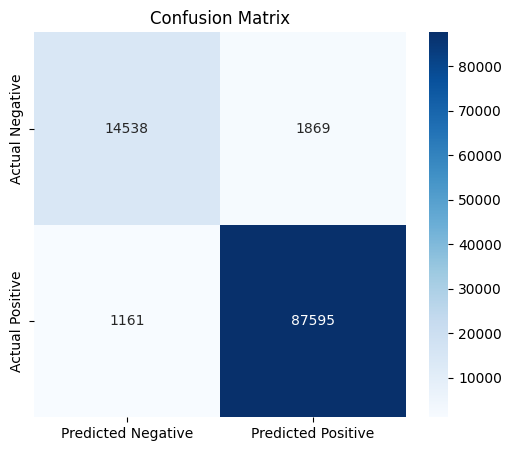

In [ ]:
# --- 5. Evaluation ---

# Predict on test set
y_pred = svm_model.predict(X_test_vec)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc*100:.2f}%")

# Print Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.show()